In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from loaddata改 import *

#### Load data


In [2]:
DATA_ROOT = r"data/CLC"

STATE_FEATURES = [
    "close_norm",
    "ret_1m",
    "ret_2m",
    "ret_3m",
    "ret_1y",
    "macd_8_24",
    "macd_16_48",
    "macd_32_96",
    "rsi_30",
]

TRAIN_END_1 = "2010-12-31"
TEST_START_1 = "2011-01-01"
TEST_END_1 = "2015-12-31"

TRAIN_END_2 = "2015-12-31"
TEST_START_2 = "2016-01-01"
TEST_END_2 = "2019-12-31"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cpu


In [3]:
data_dict, panel, missing = load_paper_rad_data(
    DATA_ROOT,
    start="2005-01-01",
    end="2019-12-31"
)

print("Loaded tickers:", len(data_dict))
print("Missing tickers:", missing)
print(panel.head())

Loaded tickers: 50
Missing tickers: []
        date    open    high     low   close  volume  open_interest ticker
0 2005-01-03  1848.0  1865.0  1831.0  1832.0    4759         117684     CC
1 2005-01-04  1830.0  1841.0  1821.0  1827.0    7117         118137     CC
2 2005-01-05  1821.0  1848.0  1820.0  1831.0    5350         118335     CC
3 2005-01-06  1824.0  1831.0  1807.0  1817.0    8218         117911     CC
4 2005-01-07  1809.0  1813.0  1764.0  1767.0   14843         119415     CC


In [4]:
feature_dict, feature_panel = build_paper_features(data_dict, dropna=False)

print(feature_panel.head())
print(feature_panel.columns.tolist())

        date ticker   open   high    low  close  volume  open_interest  \
0 2005-01-03     AN  59.27  59.33  58.47  59.00   14080          64957   
1 2005-01-04     AN  58.77  59.03  57.77  57.87   15875          66759   
2 2005-01-05     AN  57.91  58.15  57.49  57.92   12408          67640   
3 2005-01-06     AN  57.91  57.95  57.37  57.55   10195          66989   
4 2005-01-07     AN  57.68  58.12  57.10  57.23   15414          64094   

   ret_1d  ewm_vol_60  ...  ret_1y_raw  ret_1m  ret_2m  ret_3m  ret_1y  \
0     NaN         NaN  ...         NaN     NaN     NaN     NaN     NaN   
1   -1.13         NaN  ...         NaN     NaN     NaN     NaN     NaN   
2    0.05         NaN  ...         NaN     NaN     NaN     NaN     NaN   
3   -0.37         NaN  ...         NaN     NaN     NaN     NaN     NaN   
4   -0.32         NaN  ...         NaN     NaN     NaN     NaN     NaN   

   macd_8_24  macd_16_48  macd_32_96  macd_avg  rsi_30  
0        NaN         NaN         NaN       NaN     Na

In [5]:
feature_train_1 = {}
feature_test_1 = {}
feature_train_2 = {}
feature_test_2 = {}

for ticker, df in feature_dict.items():
    feature_train_1[ticker] = df[df["date"] <= TRAIN_END_1].copy()
    feature_test_1[ticker]  = df[(df["date"] >= TEST_START_1) & (df["date"] <= TEST_END_1)].copy()

    feature_train_2[ticker] = df[df["date"] <= TRAIN_END_2].copy()
    feature_test_2[ticker]  = df[(df["date"] >= TEST_START_2) & (df["date"] <= TEST_END_2)].copy()

print("Train/test split done.")

Train/test split done.


In [6]:
state_train_1 = make_state_tensors_all(feature_train_1, feature_cols=STATE_FEATURES, window=60)
state_test_1  = make_state_tensors_all(feature_test_1,  feature_cols=STATE_FEATURES, window=60)

state_train_2 = make_state_tensors_all(feature_train_2, feature_cols=STATE_FEATURES, window=60)
state_test_2  = make_state_tensors_all(feature_test_2,  feature_cols=STATE_FEATURES, window=60)

print("State tensors built.")

State tensors built.


In [7]:
PAPER_TICKERS_BY_ASSET_CLASS = {
    "Commodity": ["CC","DA","GI","JO","KC","KW","LB","NR","SB","ZA","ZC","ZF","ZG","ZH","ZI","ZK","ZL","ZN","ZO","ZP","ZR","ZT","ZU","ZW","ZZ"],
    "Equity Index": ["CA","EN","ER","ES","LX","MD","SC","SP","XU","XX","YM"],
    "Fixed Income": ["DT","FB","TY","UB","US"],
    "FX": ["AN","BN","CN","DX","FN","JN","MP","NK","SN"],
}
PAPER_TICKERS_BY_ASSET_CLASS["All"] = sorted(sum(PAPER_TICKERS_BY_ASSET_CLASS.values(), []))
BP = 0.0020
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

LR_ACTOR = 1e-4       # paper Table 1
LR_CRITIC = 1e-3      # paper Table 1
GAMMA = 0.3           # paper Table 1
BATCH_SIZE = 128      # paper Table 1
BP = 0.0020           # paper Table 1
MU = 1.0              # paper Eq.4 text
WINDOW = 60           # past 60 observations in state
HIDDEN_SIZES = [64, 32]   # paper Section 4.3
LEAKY_RELU_SLOPE = 0.01

In [8]:
a2c_models_period1 = {}

for asset_class in ["Commodity", "Equity Index", "Fixed Income", "FX"]:
    tickers = PAPER_TICKERS_BY_ASSET_CLASS[asset_class]

    valid_tickers = []
    for ticker in tickers:
        if ticker not in state_train_1:
            continue

        X = state_train_1[ticker]["X"]
        aligned_df = state_train_1[ticker]["aligned_df"]

        if not isinstance(aligned_df, pd.DataFrame):
            continue
        if len(aligned_df) == 0 or len(X) == 0:
            continue
        if not all(c in aligned_df.columns for c in ["close", "ret_1d", "ewm_vol_60"]):
            continue

        valid_tickers.append(ticker)

    print(asset_class, "valid tickers (period 1):", valid_tickers)

    envs = build_envs_from_state_dict(
        state_train_1,
        tickers=valid_tickers,
        sigma_target=0.064,   # assumption used here
        bp=BP,
        mu=MU,
    )

    if len(envs) == 0:
        print(f"{asset_class}: no envs in period 1")
        continue

    rollout_steps = max(1, round(BATCH_SIZE / len(envs)))
    effective_batch = rollout_steps * len(envs)

    print(
        f"{asset_class}: envs={len(envs)}, "
        f"rollout_steps={rollout_steps}, "
        f"effective_batch={effective_batch}"
    )

    trainer = PaperA2CTrainer(
        n_features=len(STATE_FEATURES),
        device=DEVICE
    )

    ckpt_path = f"a2c_{asset_class}_period1改.pt"

    start_update = 0
    if os.path.exists(ckpt_path):
        ckpt = trainer.load_checkpoint(ckpt_path, map_location=DEVICE)
        start_update = ckpt.get("extra_state", {}).get("update_idx", 0)
        print(f"resumed from {ckpt_path}, start_update={start_update}")

    # ===== Early Stopping Training Loop =====
    max_total_updates = 2000
    chunk_updates = 50
    patience = 5
    improve_tol = 1e-4

    best_reward = -np.inf
    no_improve_rounds = 0
    total_updates = start_update

    while total_updates < max_total_updates:

        print(f"\n=== {asset_class}: training chunk starting at {total_updates} ===")

        trainer.fit(
            envs=envs,
            n_updates=chunk_updates,
            rollout_steps=rollout_steps,
            log_every=10,
            checkpoint_path=ckpt_path,
            checkpoint_every=10,
            start_update=total_updates,
        )

        total_updates += chunk_updates

        recent_rewards = [x["avg_reward"] for x in trainer.train_log[-chunk_updates:]]
        mean_reward = np.mean(recent_rewards)

        print(f"{asset_class}: mean_reward (last {chunk_updates}) = {mean_reward:.6f}")

        if mean_reward > best_reward + improve_tol:
            best_reward = mean_reward
            no_improve_rounds = 0
            print("improvement")
        else:
            no_improve_rounds += 1
            print(f"no improvement ({no_improve_rounds}/{patience})")

        if no_improve_rounds >= patience:
            print(f"Early stopping triggered for {asset_class}")
            break

    a2c_models_period1[asset_class] = trainer

print("A2C period 1 training done.")

Commodity valid tickers (period 1): ['CC', 'DA', 'GI', 'JO', 'KC', 'KW', 'LB', 'NR', 'SB', 'ZA', 'ZC', 'ZF', 'ZG', 'ZI', 'ZK', 'ZL', 'ZN', 'ZO', 'ZP', 'ZR', 'ZT', 'ZW', 'ZZ']
Commodity: envs=23, rollout_steps=6, effective_batch=138
resumed from a2c_Commodity_period1改.pt, start_update=2000
Equity Index valid tickers (period 1): ['CA', 'EN', 'ER', 'ES', 'LX', 'MD', 'SC', 'SP', 'XU', 'XX', 'YM']
Equity Index: envs=11, rollout_steps=12, effective_batch=132
resumed from a2c_Equity Index_period1改.pt, start_update=2000
Fixed Income valid tickers (period 1): ['DT', 'FB', 'TY', 'UB']
Fixed Income: envs=4, rollout_steps=32, effective_batch=128
resumed from a2c_Fixed Income_period1改.pt, start_update=2000
FX valid tickers (period 1): ['AN', 'BN', 'CN', 'DX', 'FN', 'JN', 'MP', 'NK', 'SN']
FX: envs=9, rollout_steps=14, effective_batch=126
resumed from a2c_FX_period1改.pt, start_update=2000
A2C period 1 training done.


In [9]:
pnl_a2c_by_ticker_period1 = {}

for asset_class in ["Commodity", "Equity Index", "Fixed Income", "FX"]:
    if asset_class not in a2c_models_period1:
        continue

    trainer = a2c_models_period1[asset_class]
    tickers = PAPER_TICKERS_BY_ASSET_CLASS[asset_class]

    for ticker in tickers:
        if ticker not in state_test_1:
            continue

        X = state_test_1[ticker]["X"]
        aligned_df = state_test_1[ticker]["aligned_df"].copy()

        if len(X) == 0 or len(aligned_df) == 0:
            continue

        with torch.no_grad():
            x_tensor = torch.tensor(X, dtype=torch.float32, device=DEVICE)
            actions = trainer.actor.deterministic_action(x_tensor).squeeze(-1).cpu().numpy()

        aligned_df["a2c_signal"] = actions
        pnl_df = compute_pnl(aligned_df, signal_col="a2c_signal", dropna=True)

        pnl_a2c_by_ticker_period1[ticker] = pnl_df

print("A2C period 1 test pnl done.")

A2C period 1 test pnl done.


In [10]:
a2c_models_period2 = {}

for asset_class in ["Commodity", "Equity Index", "Fixed Income", "FX"]:
    tickers = PAPER_TICKERS_BY_ASSET_CLASS[asset_class]

    valid_tickers = []
    for ticker in tickers:
        if ticker not in state_train_2:
            continue

        X = state_train_2[ticker]["X"]
        aligned_df = state_train_2[ticker]["aligned_df"]

        if not isinstance(aligned_df, pd.DataFrame):
            continue
        if len(aligned_df) == 0 or len(X) == 0:
            continue
        if not all(c in aligned_df.columns for c in ["close", "ret_1d", "ewm_vol_60"]):
            continue

        valid_tickers.append(ticker)

    print(asset_class, "valid tickers (period 2):", valid_tickers)

    envs = build_envs_from_state_dict(
        state_train_2,
        tickers=valid_tickers,
        sigma_target=0.064,   # assumption used here
        bp=BP,
        mu=MU,
    )

    if len(envs) == 0:
        print(f"{asset_class}: no envs in period 2")
        continue

    rollout_steps = max(1, round(BATCH_SIZE / len(envs)))
    effective_batch = rollout_steps * len(envs)

    print(
        f"{asset_class}: envs={len(envs)}, "
        f"rollout_steps={rollout_steps}, "
        f"effective_batch={effective_batch}"
    )

    trainer = PaperA2CTrainer(
        n_features=len(STATE_FEATURES),
        device=DEVICE
    )

    ckpt_path = f"a2c_{asset_class}_period2改.pt"

    start_update = 0
    if os.path.exists(ckpt_path):
        ckpt = trainer.load_checkpoint(ckpt_path, map_location=DEVICE)
        start_update = ckpt.get("extra_state", {}).get("update_idx", 0)
        print(f"resumed from {ckpt_path}, start_update={start_update}")

    # ===== Early Stopping Training Loop =====
    max_total_updates = 2000
    chunk_updates = 50
    patience = 5
    improve_tol = 1e-4

    best_reward = -np.inf
    no_improve_rounds = 0
    total_updates = start_update

    while total_updates < max_total_updates:

        print(f"\n=== {asset_class}: training chunk starting at {total_updates} ===")

        trainer.fit(
            envs=envs,
            n_updates=chunk_updates,
            rollout_steps=rollout_steps,
            log_every=10,
            checkpoint_path=ckpt_path,
            checkpoint_every=10,
            start_update=total_updates,
        )

        total_updates += chunk_updates

        recent_rewards = [x["avg_reward"] for x in trainer.train_log[-chunk_updates:]]
        mean_reward = np.mean(recent_rewards)

        print(f"{asset_class}: mean_reward (last {chunk_updates}) = {mean_reward:.6f}")

        if mean_reward > best_reward + improve_tol:
            best_reward = mean_reward
            no_improve_rounds = 0
            print("improvement")
        else:
            no_improve_rounds += 1
            print(f"no improvement ({no_improve_rounds}/{patience})")

        if no_improve_rounds >= patience:
            print(f"Early stopping triggered for {asset_class}")
            break

    a2c_models_period2[asset_class] = trainer

print("A2C period 2 training done.")

Commodity valid tickers (period 2): ['CC', 'DA', 'GI', 'JO', 'KC', 'KW', 'LB', 'NR', 'SB', 'ZA', 'ZC', 'ZF', 'ZG', 'ZI', 'ZK', 'ZL', 'ZN', 'ZO', 'ZP', 'ZR', 'ZT', 'ZW', 'ZZ']
Commodity: envs=23, rollout_steps=6, effective_batch=138
resumed from a2c_Commodity_period2改.pt, start_update=2000
Equity Index valid tickers (period 2): ['CA', 'EN', 'ER', 'ES', 'LX', 'MD', 'SC', 'SP', 'XU', 'XX', 'YM']
Equity Index: envs=11, rollout_steps=12, effective_batch=132
resumed from a2c_Equity Index_period2改.pt, start_update=2000
Fixed Income valid tickers (period 2): ['DT', 'FB', 'TY', 'UB']
Fixed Income: envs=4, rollout_steps=32, effective_batch=128
resumed from a2c_Fixed Income_period2改.pt, start_update=2000
FX valid tickers (period 2): ['AN', 'BN', 'CN', 'DX', 'FN', 'JN', 'MP', 'NK', 'SN']
FX: envs=9, rollout_steps=14, effective_batch=126
resumed from a2c_FX_period2改.pt, start_update=2000
A2C period 2 training done.


In [11]:
pnl_a2c_by_ticker_period2 = {}

for asset_class in ["Commodity", "Equity Index", "Fixed Income", "FX"]:
    if asset_class not in a2c_models_period2:
        continue

    trainer = a2c_models_period2[asset_class]
    tickers = PAPER_TICKERS_BY_ASSET_CLASS[asset_class]

    for ticker in tickers:
        if ticker not in state_test_2:
            continue

        X = state_test_2[ticker]["X"]
        aligned_df = state_test_2[ticker]["aligned_df"].copy()

        if len(X) == 0 or len(aligned_df) == 0:
            continue

        with torch.no_grad():
            x_tensor = torch.tensor(X, dtype=torch.float32, device=DEVICE)
            actions = trainer.actor.deterministic_action(x_tensor).squeeze(-1).cpu().numpy()

        aligned_df["a2c_signal"] = actions
        pnl_df = compute_pnl(aligned_df, signal_col="a2c_signal", dropna=True)

        pnl_a2c_by_ticker_period2[ticker] = pnl_df

print("A2C period 2 test pnl done.")

A2C period 2 test pnl done.


In [12]:
pnl_a2c_by_ticker = {}

all_tickers = sorted(set(list(pnl_a2c_by_ticker_period1.keys()) + list(pnl_a2c_by_ticker_period2.keys())))

for ticker in all_tickers:
    parts = []
    if ticker in pnl_a2c_by_ticker_period1:
        parts.append(pnl_a2c_by_ticker_period1[ticker])
    if ticker in pnl_a2c_by_ticker_period2:
        parts.append(pnl_a2c_by_ticker_period2[ticker])

    if len(parts) > 0:
        pnl_a2c_by_ticker[ticker] = (
            pd.concat(parts, ignore_index=True)
            .sort_values("date")
            .reset_index(drop=True)
        )

print("A2C full test pnl done.")

A2C full test pnl done.


In [13]:
ticker_to_asset1={}
for i in PAPER_TICKERS_BY_ASSET_CLASS.values():
    for j in i:
        if j in PAPER_TICKERS_BY_ASSET_CLASS['Commodity']:
            ticker_to_asset1[j]='Commodity'
        elif j in PAPER_TICKERS_BY_ASSET_CLASS['Equity Index']:
            ticker_to_asset1[j]='Equity Index'
        elif j in PAPER_TICKERS_BY_ASSET_CLASS['Fixed Income']:
            ticker_to_asset1[j]='Fixed Income'
        else:
            ticker_to_asset1[j]='Forex'

a2c_results = build__by_asset(pnl_a2c_by_ticker, ticker_to_asset1)
a2c_results

{'Commodity': (array(['2011-04-01T00:00:00.000000000', '2011-04-04T00:00:00.000000000',
         '2011-04-05T00:00:00.000000000', ...,
         '2019-12-27T00:00:00.000000000', '2019-12-30T00:00:00.000000000',
         '2019-12-31T00:00:00.000000000'],
        shape=(2143,), dtype='datetime64[ns]'),
  array([-0.00355406,  0.01763261,  0.0311795 , ..., -1.98471477,
         -1.97714536, -1.97948749], shape=(2143,))),
 'Equity Index': (array(['2011-03-30T00:00:00.000000000', '2011-03-31T00:00:00.000000000',
         '2011-04-01T00:00:00.000000000', ...,
         '2019-12-27T00:00:00.000000000', '2019-12-30T00:00:00.000000000',
         '2019-12-31T00:00:00.000000000'],
        shape=(2198,), dtype='datetime64[ns]'),
  array([0.0470777 , 0.02028698, 0.06901169, ..., 4.82299699, 4.76938769,
         4.78022372], shape=(2198,))),
 'Fixed Income': (array(['2011-03-30T00:00:00.000000000', '2011-03-31T00:00:00.000000000',
         '2011-04-01T00:00:00.000000000', ...,
         '2019-12-27T00:0

In [14]:
series_dict = {}

for asset, (dates, curve) in a2c_results.items():
    if dates is None:
        continue
    series_dict[asset] = pd.Series(curve, index=pd.to_datetime(dates))

df_wide = pd.DataFrame(series_dict)
df_wide.to_csv("a2c_results_wide改.csv")

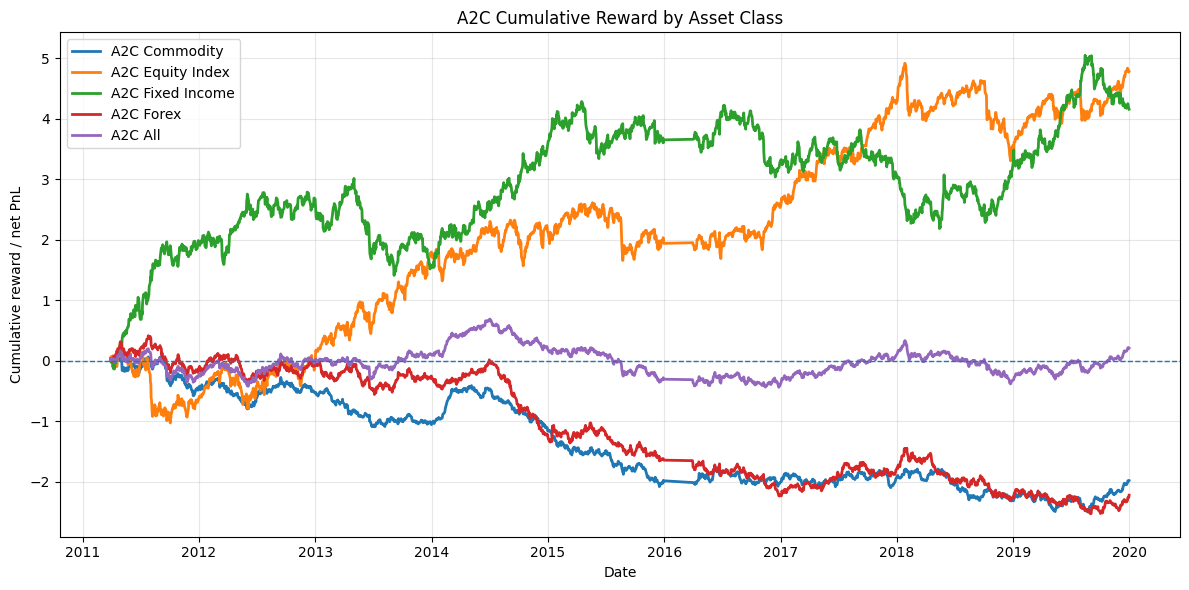

In [15]:
asset_order = ["Commodity", "Equity Index", "Fixed Income", "Forex", "All"]

plt.figure(figsize=(12, 6))

for asset in asset_order:
    dates, curve = a2c_results.get(asset, (None, None))
    if dates is None or curve is None:
        continue

    a2c_curve = pd.Series(curve, index=pd.to_datetime(dates)).sort_index()
    plt.plot(a2c_curve.index, a2c_curve.values, linewidth=2, label=f"A2C {asset}")

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.title("A2C Cumulative Reward by Asset Class")
plt.xlabel("Date")
plt.ylabel("Cumulative reward / net PnL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Transaction cost robustness

This section keeps the trained A2C signals fixed and recomputes the reward under different transaction-cost assumptions.


In [16]:
def build_transaction_cost_robustness(
    pnl_by_ticker,
    ticker_to_asset,
    cost_bps,
    signal_col="a2c_signal",
    sigma_target=0.064,
    mu=1.0,
):
    """
    Recompute A2C evaluation reward under several transaction-cost levels.

    This keeps the trained A2C signal fixed. For each cost level, it calls
    compute_pnl() again with a different bp value, then builds cumulative
    reward curves by asset class.
    """
    curves_by_cost = {}
    summary_rows = []

    for cost_bp in cost_bps:
        bp_decimal = cost_bp / 10000.0
        pnl_by_ticker_cost = {}

        for ticker, df in pnl_by_ticker.items():
            if df is None or len(df) == 0:
                continue
            if signal_col not in df.columns:
                continue

            pnl_by_ticker_cost[ticker] = compute_pnl(
                df=df.copy(),
                signal_col=signal_col,
                sigma_target=sigma_target,
                bp=bp_decimal,
                mu=mu,
                dropna=False,
            )

        curves = build__by_asset(pnl_by_ticker_cost, ticker_to_asset)
        curves_by_cost[cost_bp] = curves

        for asset_class, (dates, curve) in curves.items():
            if dates is None or curve is None or len(curve) == 0:
                final_value = np.nan
            else:
                final_value = float(curve[-1])

            summary_rows.append({
                "cost_bp": cost_bp,
                "bp_decimal": bp_decimal,
                "asset_class": asset_class,
                "final_cumulative_reward": final_value,
            })

    summary = pd.DataFrame(summary_rows)
    return curves_by_cost, summary

In [17]:
TC_BPS = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45]

# Reprice the same A2C signals under each cost level.
# This does not retrain the models, we only changes the bp input in compute_pnl().
tc_robustness_curves, tc_robustness_summary = build_transaction_cost_robustness(
    pnl_by_ticker=pnl_a2c_by_ticker,
    ticker_to_asset=ticker_to_asset1,
    cost_bps=TC_BPS,
    signal_col="a2c_signal",
    sigma_target=0.064,
    mu=MU,
)

tc_summary_wide = (
    tc_robustness_summary
    .pivot(index="cost_bp", columns="asset_class", values="final_cumulative_reward")
    .reset_index()
)

tc_summary_wide.to_csv("a2c_transaction_cost_robustness_summary.csv", index=False)
tc_summary_wide

asset_class,cost_bp,All,Commodity,Equity Index,Fixed Income,Forex
0,1,0.860090,-1.683478,5.322119,6.444036,-1.381010
1,5,0.723095,-1.750453,5.207093,5.958350,-1.555965
2,10,0.551853,-1.834173,5.063309,5.351242,-1.774660
3,15,0.380610,-1.917893,4.919526,4.744135,-1.993354
4,20,0.209367,-2.001612,4.775743,4.137027,-2.212048
5,25,0.038125,-2.085332,4.631960,3.529920,-2.430742
6,30,-0.133118,-2.169051,4.488176,2.922812,-2.649437
7,35,-0.304361,-2.252771,4.344393,2.315704,-2.868131
8,40,-0.475603,-2.336490,4.200610,1.708597,-3.086825
9,45,-0.646846,-2.420210,4.056826,1.101489,-3.305520


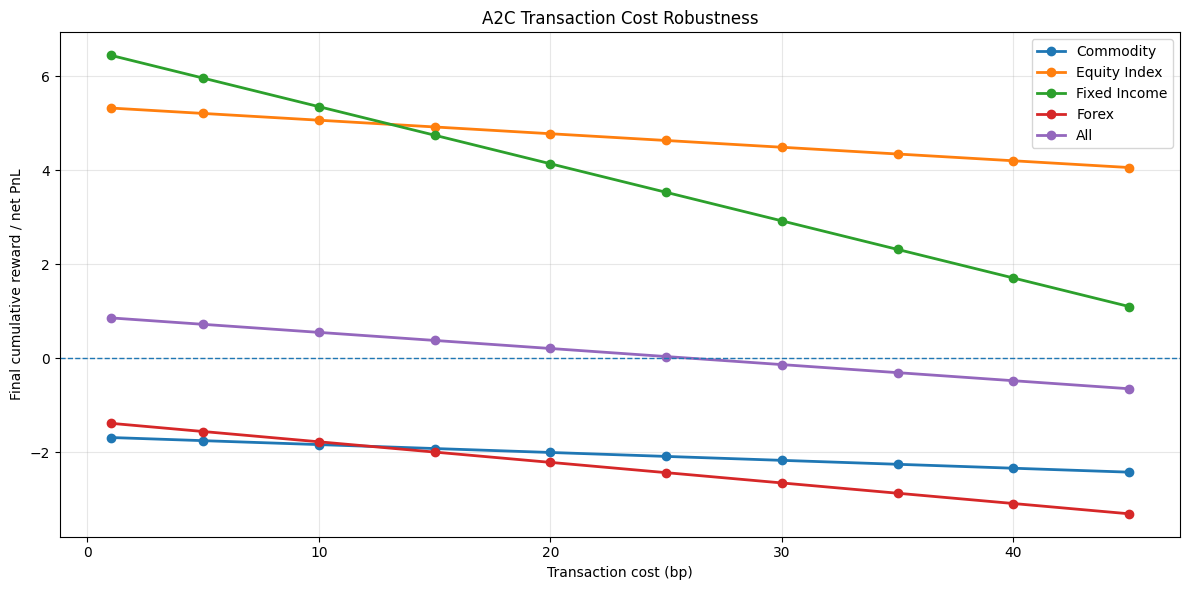

In [18]:
asset_order = ["Commodity", "Equity Index", "Fixed Income", "Forex", "All"]

plt.figure(figsize=(12, 6))

for asset in asset_order:
    if asset not in tc_summary_wide.columns:
        continue
    plt.plot(
        tc_summary_wide["cost_bp"],
        tc_summary_wide[asset],
        marker="o",
        linewidth=2,
        label=asset,
    )

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.title("A2C Transaction Cost Robustness")
plt.xlabel("Transaction cost (bp)")
plt.ylabel("Final cumulative reward / net PnL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

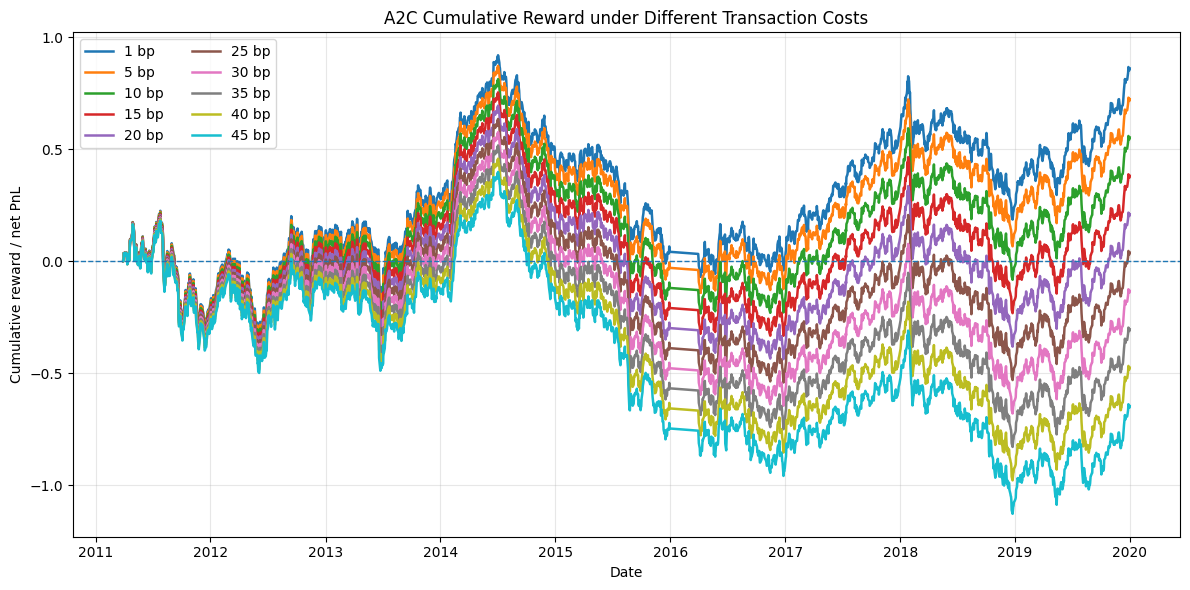

In [22]:
plt.figure(figsize=(12, 6))

for cost_bp in TC_BPS:
    dates, curve = tc_robustness_curves[cost_bp].get("All", (None, None))
    if dates is None or curve is None:
        continue

    s = pd.Series(curve, index=pd.to_datetime(dates)).sort_index()
    plt.plot(s.index, s.values, linewidth=1.8, label=f"{cost_bp} bp")

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.title("A2C Cumulative Reward under Different Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Cumulative reward / net PnL")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Transaction cost robustness: Sharpe ratio and CSV outputs

This cell uses the same fixed A2C signals and recomputes daily `net_pnl` for each transaction-cost level. Then save the final cumulative reward and annualized Sharpe ratio by asset class.

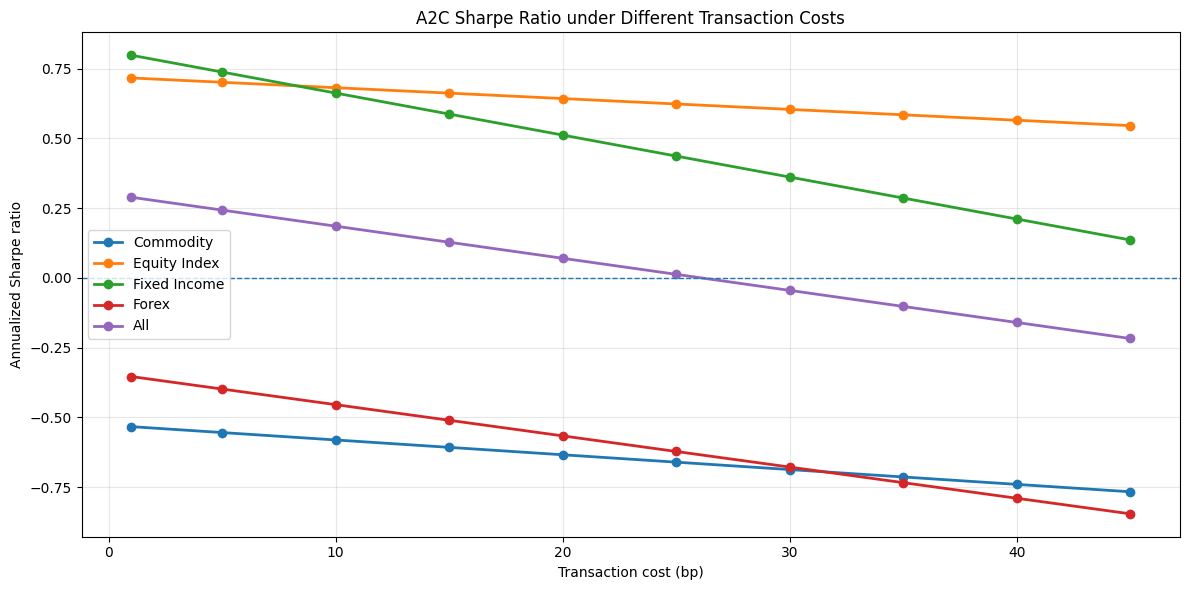

asset_class,cost_bp,Commodity,Equity Index,Fixed Income,Forex,All
0,1,-0.533102,0.716682,0.798029,-0.353607,0.289022
1,5,-0.554319,0.701135,0.737794,-0.398377,0.242964
2,10,-0.580840,0.681703,0.662503,-0.454327,0.185402
3,15,-0.607361,0.662274,0.587222,-0.510262,0.127854
4,20,-0.633883,0.642847,0.511957,-0.566181,0.070321
5,25,-0.660406,0.623423,0.436715,-0.622082,0.012803
6,30,-0.686929,0.604002,0.361501,-0.677964,-0.044698
7,35,-0.713452,0.584584,0.286322,-0.733826,-0.102183
8,40,-0.739975,0.565170,0.211185,-0.789667,-0.159650
9,45,-0.766499,0.545759,0.136095,-0.845484,-0.217098


In [20]:
# Final cumulative reward and Sharpe ratio under different transaction costs.
# This uses the same fixed A2C signals; no A2C model is retrained here.

asset_order = ["Commodity", "Equity Index", "Fixed Income", "Forex", "All"]

reward_rows = []
sharpe_rows = []

for cost_bp in TC_BPS:
    bp_decimal = cost_bp / 10000.0
    asset_series = {asset: [] for asset in asset_order}

    for ticker, df in pnl_a2c_by_ticker.items():
        if df is None or len(df) == 0:
            continue
        if "a2c_signal" not in df.columns:
            continue

        df_cost = compute_pnl(
            df=df.copy(),
            signal_col="a2c_signal",
            sigma_target=0.064,
            bp=bp_decimal,
            mu=MU,
            dropna=False,
        )

        if not all(c in df_cost.columns for c in ["date", "net_pnl"]):
            continue

        s = pd.Series(df_cost["net_pnl"].values, index=pd.to_datetime(df_cost["date"]))
        asset = ticker_to_asset1.get(ticker)

        if asset in asset_series:
            asset_series[asset].append(s)
        asset_series["All"].append(s)

    for asset in asset_order:
        series_list = asset_series[asset]

        if len(series_list) == 0:
            final_cum_reward = np.nan
            sharpe_ratio = np.nan
        else:
            daily_reward = pd.DataFrame(series_list).T.sort_index().mean(axis=1).fillna(0.0)
            final_cum_reward = float(daily_reward.cumsum().iloc[-1])

            daily_std = daily_reward.std(ddof=1)
            if pd.isna(daily_std) or daily_std == 0:
                sharpe_ratio = np.nan
            else:
                sharpe_ratio = float(np.sqrt(252) * daily_reward.mean() / daily_std)

        reward_rows.append({
            "cost_bp": cost_bp,
            "bp_decimal": bp_decimal,
            "asset_class": asset,
            "final_cumulative_reward": final_cum_reward,
        })

        sharpe_rows.append({
            "cost_bp": cost_bp,
            "bp_decimal": bp_decimal,
            "asset_class": asset,
            "annualized_sharpe": sharpe_ratio,
        })

# Long-format CSVs for read and plot later
tc_final_reward_by_asset = pd.DataFrame(reward_rows)
tc_sharpe_by_asset = pd.DataFrame(sharpe_rows)

tc_final_reward_by_asset.to_csv("a2c_tc_final_cumulative_reward_by_asset.csv", index=False)
tc_sharpe_by_asset.to_csv("a2c_tc_sharpe_by_asset.csv", index=False)

# Wide versions
tc_final_reward_wide = (
    tc_final_reward_by_asset
    .pivot(index="cost_bp", columns="asset_class", values="final_cumulative_reward")
    .reindex(columns=asset_order)
    .reset_index()
)

tc_sharpe_wide = (
    tc_sharpe_by_asset
    .pivot(index="cost_bp", columns="asset_class", values="annualized_sharpe")
    .reindex(columns=asset_order)
    .reset_index()
)

tc_final_reward_wide.to_csv("a2c_tc_final_cumulative_reward_by_asset_wide.csv", index=False)
tc_sharpe_wide.to_csv("a2c_tc_sharpe_by_asset_wide.csv", index=False)

plt.figure(figsize=(12, 6))

for asset in asset_order:
    if asset not in tc_sharpe_wide.columns:
        continue
    plt.plot(
        tc_sharpe_wide["cost_bp"],
        tc_sharpe_wide[asset],
        marker="o",
        linewidth=2,
        label=asset,
    )

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.title("A2C Sharpe Ratio under Different Transaction Costs")
plt.xlabel("Transaction cost (bp)")
plt.ylabel("Annualized Sharpe ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

tc_sharpe_wide

#### A2C reproduction comparison with Paper Table 3 (Risk diagnostics also included)

This cell compares this project's A2C results with the A2C rows in Table 3: Experiment Results for the Raw Signal.


In [21]:
# Compare this project's A2C results with the A2C rows in the paper's Table 3.
# The project side is computed from compute_pnl(...)["net_pnl"] using the fixed A2C signals.
# The paper result being used to compare is the A2C row from Table 3: Experiment Results for the Raw Signal.

try:
    table3_a2c_compare_wide = build_a2c_table3_comparison_wide(
        pnl_by_ticker=pnl_a2c_by_ticker,
        ticker_to_asset=ticker_to_asset1,
        cost_bp=20,                 # 20 bp = 0.0020, the baseline cost used in the paper-style setup
        signal_col="a2c_signal",
        sigma_target=0.064,
        mu=MU,
        annualization=252,
    )
except NameError:
    def compute_table3_like_metrics_from_daily_pnl(daily_pnl, annualization=252):
        s = pd.Series(daily_pnl).dropna().astype(float)
        if len(s) == 0:
            return {
                "E(R)": np.nan, "Std(R)": np.nan, "DD": np.nan, "Sharpe": np.nan,
                "Sortino": np.nan, "MDD": np.nan, "Calmar": np.nan, "% + Ret": np.nan, "Ave P/L": np.nan,
            }
        er = s.mean() * annualization
        std = s.std(ddof=1) * np.sqrt(annualization) if len(s) > 1 else np.nan
        downside = s[s < 0]
        dd = downside.std(ddof=1) * np.sqrt(annualization) if len(downside) > 1 else np.nan
        sharpe = er / std if pd.notna(std) and std != 0 else np.nan
        sortino = er / dd if pd.notna(dd) and dd != 0 else np.nan
        cum = s.fillna(0.0).cumsum()
        drawdown = cum.cummax() - cum
        mdd = drawdown.max() if len(drawdown) else np.nan
        calmar = er / mdd if pd.notna(mdd) and mdd != 0 else np.nan
        pct_pos = (s > 0).mean()
        avg_profit = s[s > 0].mean()
        avg_loss = s[s < 0].mean()
        ave_pl = avg_profit / abs(avg_loss) if pd.notna(avg_profit) and pd.notna(avg_loss) and avg_loss != 0 else np.nan
        return {
            "E(R)": er, "Std(R)": std, "DD": dd, "Sharpe": sharpe, "Sortino": sortino,
            "MDD": mdd, "Calmar": calmar, "% + Ret": pct_pos, "Ave P/L": ave_pl,
        }

    paper_a2c_table3 = {
        "Commodity": {"E(R)": 0.072, "Std(R)": 0.163, "DD": 0.098, "Sharpe": 0.440, "Sortino": 0.729, "MDD": 0.099, "Calmar": 0.161, "% + Ret": 0.487, "Ave P/L": 1.151},
        "Equity Index": {"E(R)": 0.293, "Std(R)": 0.629, "DD": 0.427, "Sharpe": 0.466, "Sortino": 0.686, "MDD": 0.193, "Calmar": 0.214, "% + Ret": 0.533, "Ave P/L": 0.965},
        "Fixed Income": {"E(R)": 0.852, "Std(R)": 1.345, "DD": 0.806, "Sharpe": 0.633, "Sortino": 1.057, "MDD": 0.128, "Calmar": 0.397, "% + Ret": 0.517, "Ave P/L": 1.039},
        "Forex": {"E(R)": 0.159, "Std(R)": 0.455, "DD": 0.267, "Sharpe": 0.349, "Sortino": 0.592, "MDD": 0.081, "Calmar": 0.193, "% + Ret": 0.507, "Ave P/L": 1.034},
        "All": {"E(R)": 0.214, "Std(R)": 0.221, "DD": 0.134, "Sharpe": 0.969, "Sortino": 1.601, "MDD": 0.009, "Calmar": 0.672, "% + Ret": 0.538, "Ave P/L": 1.014},
    }

    asset_order = ["Commodity", "Equity Index", "Fixed Income", "Forex", "All"]
    metric_order = ["E(R)", "Std(R)", "DD", "Sharpe", "Sortino", "MDD", "Calmar", "% + Ret", "Ave P/L"]
    bp_decimal = 20 / 10000.0
    by_asset = {asset: [] for asset in asset_order}

    for ticker, df in pnl_a2c_by_ticker.items():
        if df is None or len(df) == 0 or "a2c_signal" not in df.columns:
            continue
        asset = ticker_to_asset1.get(ticker)
        if asset not in by_asset:
            continue
        pnl_df = compute_pnl(df, signal_col="a2c_signal", sigma_target=0.064, bp=bp_decimal, mu=MU, dropna=True)
        if len(pnl_df) == 0:
            continue
        s = pd.Series(pnl_df["net_pnl"].values, index=pd.to_datetime(pnl_df["date"]))
        by_asset[asset].append(s)
        by_asset["All"].append(s)

    project_metrics = {}
    for asset in asset_order:
        if len(by_asset[asset]) == 0:
            project_metrics[asset] = compute_table3_like_metrics_from_daily_pnl([])
        else:
            port = pd.DataFrame(by_asset[asset]).T.sort_index().mean(axis=1)
            project_metrics[asset] = compute_table3_like_metrics_from_daily_pnl(port)

    rows = []
    for metric in metric_order:
        row = {"metric": metric, "cost_bp": 20}
        for asset in asset_order:
            project_value = project_metrics[asset].get(metric, np.nan)
            paper_value = paper_a2c_table3[asset].get(metric, np.nan)
            row[f"{asset} Project A2C"] = project_value
            row[f"{asset} Paper Table 3 A2C"] = paper_value
            row[f"{asset} Difference"] = project_value - paper_value if pd.notna(project_value) and pd.notna(paper_value) else np.nan
        rows.append(row)
    table3_a2c_compare_wide = pd.DataFrame(rows)

table3_a2c_compare_wide.to_csv("a2c_table3_raw_signal_a2c_comparison_wide.csv", index=False)

display(table3_a2c_compare_wide)
print("Saved: a2c_table3_raw_signal_a2c_comparison_wide.csv")

,metric,cost_bp,Commodity Project A2C,Commodity Paper Table 3 A2C,Commodity Difference,Equity Index Project A2C,Equity Index Paper Table 3 A2C,Equity Index Difference,Fixed Income Project A2C,Fixed Income Paper Table 3 A2C,Fixed Income Difference,Forex Project A2C,Forex Paper Table 3 A2C,Forex Difference,All Project A2C,All Paper Table 3 A2C,All Difference
0,E(R),20,-0.235594,0.072,-0.307594,0.548036,0.293,0.255036,0.475174,0.852,-0.376826,-0.253035,0.159,-0.412035,0.023939,0.214,-0.190061
1,Std(R),20,0.371494,0.163,0.208494,0.852126,0.629,0.223126,0.927728,1.345,-0.417272,0.446713,0.455,-0.008287,0.340263,0.221,0.119263
2,DD,20,0.248944,0.098,0.150944,0.671485,0.427,0.244485,0.605823,0.806,-0.200177,0.291841,0.267,0.024841,0.238749,0.134,0.104749
3,Sharpe,20,-0.634180,0.440,-1.074180,0.643140,0.466,0.177140,0.512191,0.633,-0.120809,-0.566438,0.349,-0.915438,0.070353,0.969,-0.898647
4,Sortino,20,-0.946372,0.729,-1.675372,0.816156,0.686,0.130156,0.784345,1.057,-0.272655,-0.867029,0.592,-1.459029,0.100267,1.601,-1.500733
5,MDD,20,2.565860,0.099,2.466860,1.611485,0.193,1.418485,2.112488,0.128,1.984488,2.949699,0.081,2.868699,1.131578,0.009,1.122578
6,Calmar,20,-0.091819,0.161,-0.252819,0.340081,0.214,0.126081,0.224936,0.397,-0.172064,-0.085783,0.193,-0.278783,0.021155,0.672,-0.650845
7,% + Ret,20,0.496964,0.487,0.009964,0.547359,0.533,0.014359,0.521878,0.517,0.004878,0.487517,0.507,-0.019483,0.518149,0.538,-0.019851
8,Ave P/L,20,0.912695,1.151,-0.238305,0.923284,0.965,-0.041716,0.996061,1.039,-0.042939,0.956950,1.034,-0.077050,0.940785,1.014,-0.073215


Saved: a2c_table3_raw_signal_a2c_comparison_wide.csv
